# Fixed-pattern correction: example usage

Channels 2, 3, 5, 6 (and to a lesser extent 1) show a temperature-dependent spatial pattern that survives the onboard NUC and the L1 destriping step. This notebook shows applying the pre-built correction table, then building a custom one on a smaller frame pool.

In [1]:
import xarray as xr
from velox_tools.correction import build_correction_table, apply_correction

## Apply the shipped correction table

In [2]:
table = xr.open_dataset('../data/correction_table_v1.nc')
table

ERROR 1: PROJ: proj_create_from_database: Open of /projekt_agmwend/home_rad/Joshua/micromamba/envs/mamba_josh/share/proj failed


<xarray.Dataset> Size: 45MB
Dimensions:   (band: 5, Tbin: 7, x: 635, y: 507)
Coordinates:
  * band      (band) int64 40B 0 1 2 3 4
  * Tbin      (Tbin) float64 56B -37.5 -32.5 -27.5 -22.5 -17.5 -12.5 -7.5
  * x         (x) int64 5kB 0 1 2 3 4 5 6 7 ... 627 628 629 630 631 632 633 634
  * y         (y) int64 4kB 0 1 2 3 4 5 6 7 ... 499 500 501 502 503 504 505 506
Data variables:
    pattern   (band, Tbin, x, y) float32 45MB ...
    n_frames  (band, Tbin) float64 280B ...
Attributes:
    method:              poly_detrend+robust_median
    order:               2
    bin_width:           5.0
    min_frames_per_bin:  30
    max_frames_per_bin:  800
    description:         VELOX fixed-pattern correction table -- see velox_to...

In [3]:
# a real HALO-AC3 scene, channel 3 (band index 2)
ds = xr.open_zarr('/projekt_agmwend/home_rad/Joshua/HALO-AC3_VELOX_sea_ice/2022-04-04_v_0.1.zarr')
scene = ds.isel(band=2).sel(time=slice('2022-04-04T10:00:00', '2022-04-04T10:00:30')).load()

bt_2d = scene['BT_2D']
scene_bt = scene['BT_Center']
corrected = apply_correction(bt_2d, scene_bt, table, band=2)

raw_std = bt_2d.std(dim=['x', 'y']).mean().item()
corr_std = corrected.std(dim=['x', 'y']).mean().item()
print(f'scene BT range: {float(scene_bt.min()):.1f} to {float(scene_bt.max()):.1f} C')
print(f'raw spatial std:       {raw_std:.4f} K')
print(f'corrected spatial std: {corr_std:.4f} K')
print(f'reduction: {100*(1 - corr_std/raw_std):.1f}%')

scene BT range: -38.3 to -31.6 C
raw spatial std:       2.7329 K
corrected spatial std: 2.5133 K
reduction: 8.0%


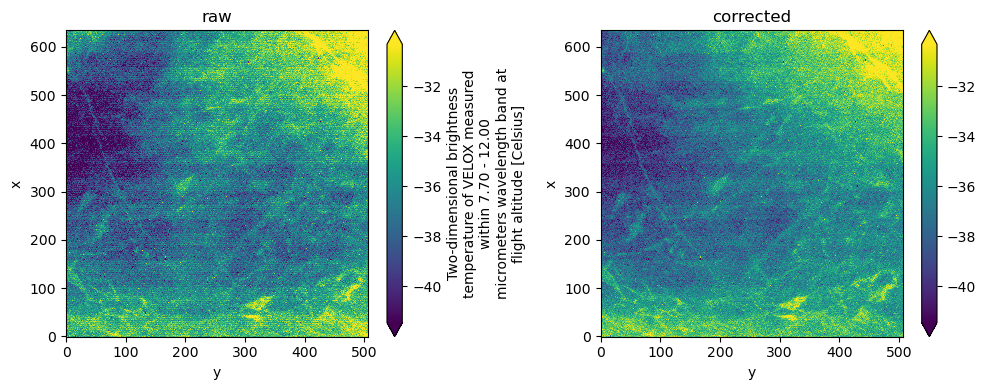

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vmin, vmax = float(bt_2d.isel(time=0).quantile(0.02)), float(bt_2d.isel(time=0).quantile(0.98))
bt_2d.isel(time=0).plot(ax=axes[0], vmin=vmin, vmax=vmax, add_colorbar=True)
axes[0].set_title('raw')
corrected.isel(time=0).plot(ax=axes[1], vmin=vmin, vmax=vmax, add_colorbar=True)
axes[1].set_title('corrected')
plt.tight_layout()

## Building a custom table

`build_correction_table` needs a large, varied frame pool -- a handful of hand-picked scenes isn't enough for the per-bin median to average out real scene structure (see the module docstring for the validation behind this). This example uses a small, fast slice just to show the call; for a real table use hundreds+ of frames per bin, e.g. from a clear-sky-flagged archive spanning many flights.

In [5]:
small_ds = ds.isel(band=[2]).sel(time=slice('2022-04-04T09:00:00', '2022-04-04T11:00:00')).load()
small_ds = small_ds.rename({'band': 'band'})  # BT_Center/BT_2D already have a band dim
custom_table = build_correction_table(
    small_ds, bands=[0], bin_width=5.0, min_frames_per_bin=20, max_frames_per_bin=200,
)
custom_table

<xarray.Dataset> Size: 12MB
Dimensions:   (band: 1, Tbin: 9, x: 635, y: 507)
Coordinates:
  * band      (band) int64 8B 0
  * Tbin      (Tbin) float64 72B -42.5 -37.5 -32.5 -27.5 ... -12.5 -7.5 -2.5
  * x         (x) int64 5kB 0 1 2 3 4 5 6 7 ... 627 628 629 630 631 632 633 634
  * y         (y) int64 4kB 0 1 2 3 4 5 6 7 ... 499 500 501 502 503 504 505 506
Data variables:
    pattern   (band, Tbin, x, y) float32 12MB -2.696 -2.801 ... 0.7812 0.8297
    n_frames  (band, Tbin) float64 72B 200.0 200.0 200.0 ... 78.0 130.0 200.0
Attributes:
    method:              poly_detrend+robust_median
    order:               2
    bin_width:           5.0
    min_frames_per_bin:  20
    max_frames_per_bin:  200
    description:         VELOX fixed-pattern correction table -- see velox_to...